# Tetouan City Power Consumption, my Task 1 notebook

_Task 1 by Jean Muhire._

This is the part of the group project that I took ownership of, and my job was to really get to know the data before anyone else built anything on top of it, so what you are reading here is my exploration from start to finish. The dataset itself covers the electricity that the city of Tetouan in Morocco used during the whole of 2017, and the clever thing about it is that a reading was taken every ten minutes for three separate zones of the city, and right next to each power reading there is also the weather at that exact moment, which gave me plenty of things to play with.

The way I walk through it below is more or less the order I actually did it in, so I begin by loading the file and getting a feel for the time range, how often the measurements happen and whether there is anything missing, then I move on to six questions that I wanted answered, and for every single one of them I drew at least one picture and wrote down what I honestly think it means. After the questions I build the features that the rest of the project depends on, and I finish by training two different models and putting their scores side by side so I could pick a winner. One thing I want to say up front is that my target the whole way through is the total demand of the city, which I get by simply adding the three zone columns together into one number.


## A. Getting to know the data

In [1]:
# These are all the libraries I lean on across the notebook.
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I set a theme here purely because the default plots look a bit plain to me.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# I add my src folder to the path so I can reuse the very same feature code later.
sys.path.append(os.path.abspath("../src"))
import preprocessing as pp
print("preprocessing module loaded from:", pp.__file__)


preprocessing module loaded from: C:\Users\USER\tetouan-power-forecast\src\preprocessing.py


In [2]:
# My load_raw helper reads the file, fixes the date, sorts by time and sets the index.
df = pp.load_raw("../data/powerconsumption.csv")

# Then I add the target column, which is just the three zones added up.
df = pp.add_total_consumption(df)

print("Shape:", df.shape)
df.head()


Shape: (52416, 9)


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,TotalConsumption
Datetime,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


### The time range and how often it is measured

Before I trusted the data with anything serious I wanted to be completely sure it behaves the way I assumed it would, so the first check I ran was on the calendar side of things, because if the dates were jumping around or if some ten minute slots were missing then every lag feature I planned to build later would quietly break without warning me. To test this I looked at the earliest and the latest timestamp to confirm the year really is 2017 from beginning to end, and then I measured the gap between every pair of neighbouring rows, and my hope was that a single value of ten minutes would show up for all of them, which is exactly the kind of tidy regular series that makes the rest of the work much safer.

In [3]:
print("Start:", df.index.min())
print("End:  ", df.index.max())
print("Number of rows:", len(df))

# If the series is truly regular then only one gap value should appear here.
gaps = df.index.to_series().diff().dropna().value_counts()
print("Gaps between rows:")
print(gaps)


Start: 2017-01-01 00:00:00
End:   2017-12-30 23:50:00
Number of rows: 52416
Gaps between rows:
Datetime
0 days 00:10:00    52415
Name: count, dtype: int64


### Missing values and the way I chose to deal with them

Since the brief made a point of asking how missing values were handled, I took this part seriously and ran the usual count below, and the answer that came back was that there is nothing missing at all across any of the columns, which honestly made me happy because it meant the raw file was in good shape and I did not have to make awkward guesses to fill holes that were never there. The only empty values that appear anywhere in my work are the ones that I create myself a little later on, because the moment I ask for the demand of one day ago the very first rows simply have no earlier day to point back to, and rather than invent a fake number for those rows I decided the cleanest and most honest move was to drop them, and since that only throws away a hundred and forty four rows out of more than fifty thousand it costs me almost nothing while keeping me from lying to the model about a past that never happened.

In [4]:
# This is the missing value check that the brief specifically asked for.
print("Missing values per column:")
print(df.isnull().sum())
print("Total missing values:", int(df.isnull().sum().sum()))


Missing values per column:
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
TotalConsumption          0
dtype: int64
Total missing values: 0


In [5]:
# These are the summary statistics for all of the numeric columns.
df.describe().round(2)


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,TotalConsumption
count,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00
mean,18.81,68.26,1.96,182.70,75.03,32344.97,21042.51,17835.41,71222.89
std,5.82,15.55,2.35,264.40,124.21,7130.56,5201.47,6622.17,17143.14
min,3.25,11.34,0.05,0.00,0.01,13895.70,8560.08,5935.17,36785.04
25%,14.41,58.31,0.08,0.06,0.12,26310.67,16980.77,13129.33,56499.07
50%,18.78,69.86,0.09,5.04,4.46,32265.92,20823.17,16415.12,69788.79
75%,22.89,81.40,4.92,319.60,101.00,37309.02,24713.72,21624.10,83749.17
max,40.01,94.80,6.48,1163.00,936.00,52204.40,37408.86,47598.33,134208.15


### Looking at the distributions

To build a mental picture of what each column looks like I drew a histogram for every numeric field and then a set of box plots on top of that, because the histograms are the quickest way for me to see the general shape and spread of the values while the box plots make the outliers and the very different scales jump straight out at me, and seeing the weather numbers sitting next to the power numbers really drove home that they live in completely different ranges and would need care later.

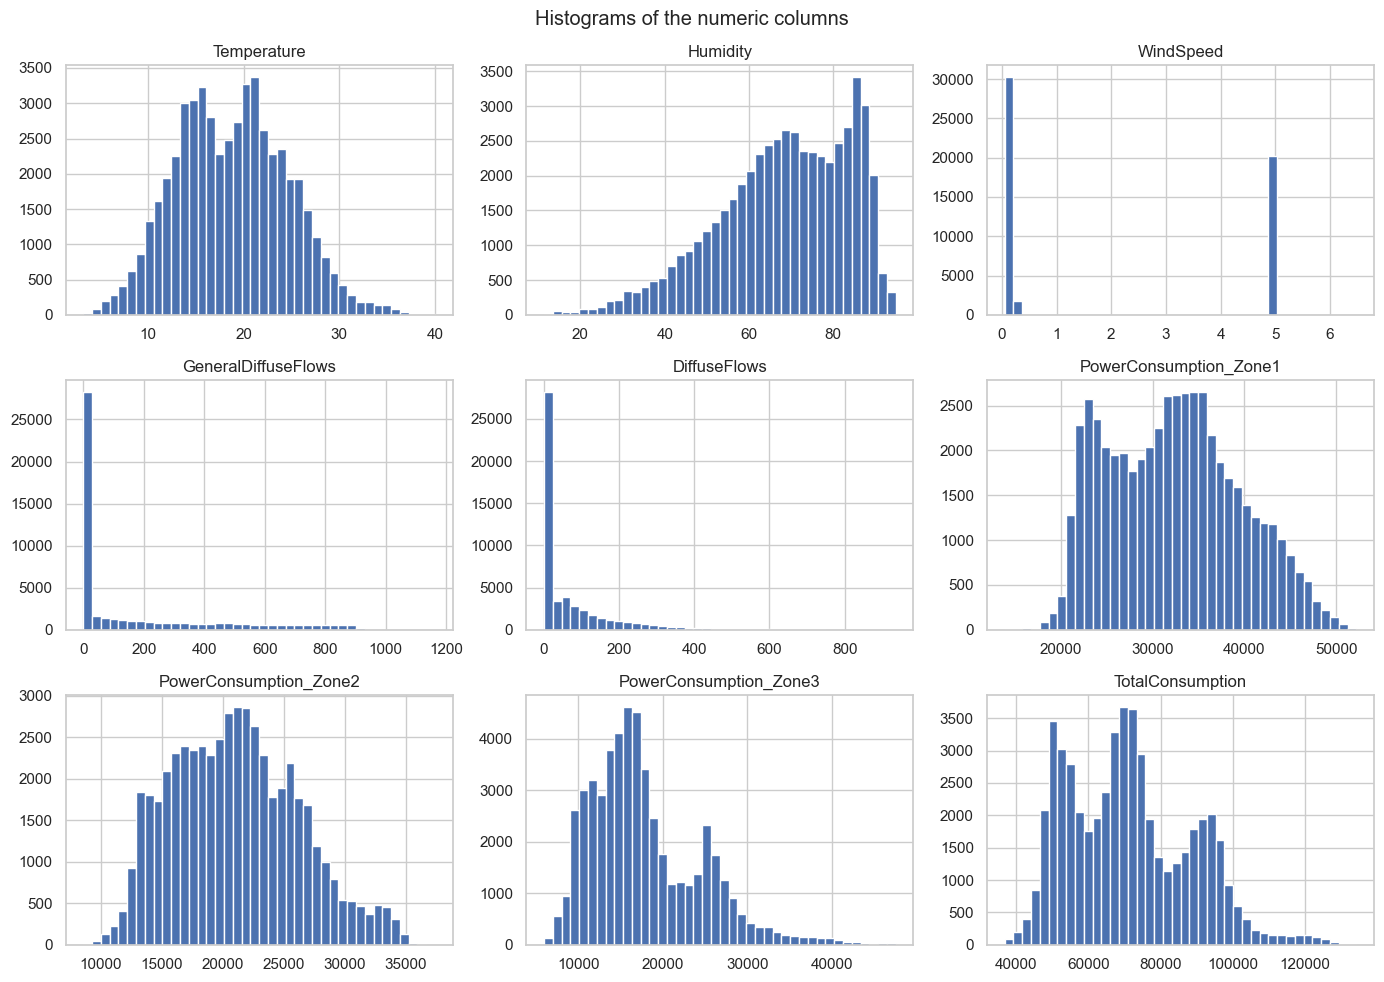

In [6]:
# Histograms of every numeric column so I can see their shapes at a glance.
num_cols = ["Temperature", "Humidity", "WindSpeed",
            "GeneralDiffuseFlows", "DiffuseFlows",
            "PowerConsumption_Zone1", "PowerConsumption_Zone2",
            "PowerConsumption_Zone3", "TotalConsumption"]
df[num_cols].hist(bins=40, figsize=(14, 10))
plt.suptitle("Histograms of the numeric columns")
plt.tight_layout()
plt.show()


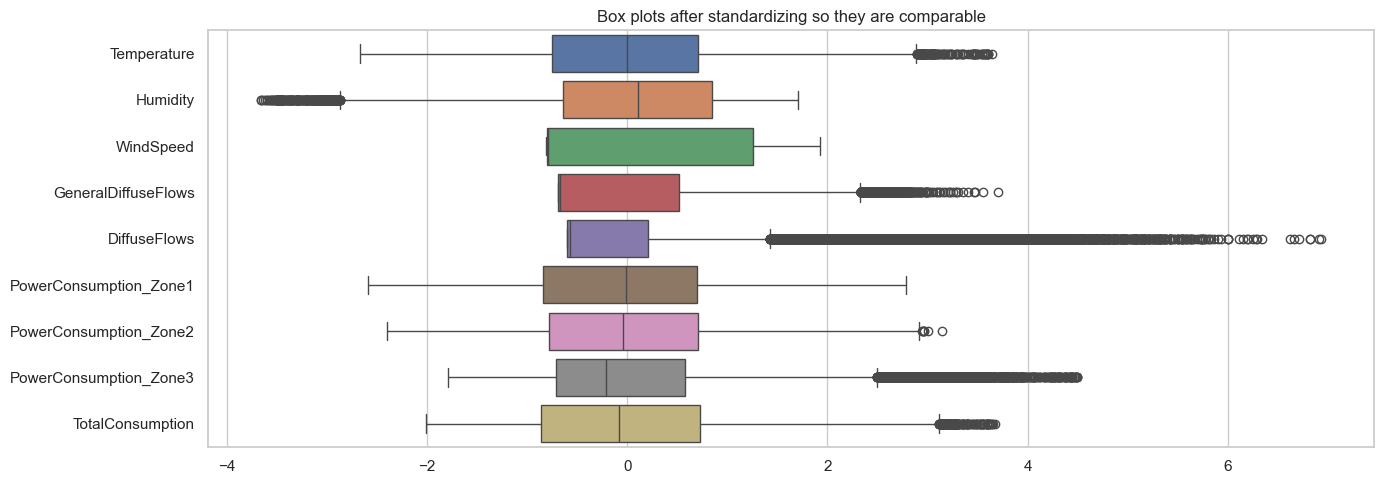

In [7]:
# Box plots for the same columns to spot outliers and spread.
plt.figure(figsize=(14, 5))
# The columns sit on very different scales so I standardize them just for this picture.
standardized = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
sns.boxplot(data=standardized, orient="h")
plt.title("Box plots after standardizing so they are comparable")
plt.tight_layout()
plt.show()


## B. The questions I wanted answered

The brief asked for at least five questions with a plot and an interpretation for each, and it also insisted that two of them use lag features and moving averages, but I ended up with six because a couple of extra ideas came to me naturally while I was digging around, and the two required ones are questions four and five which I have marked clearly.

### Q1. How does the total demand change across the year and the seasons?

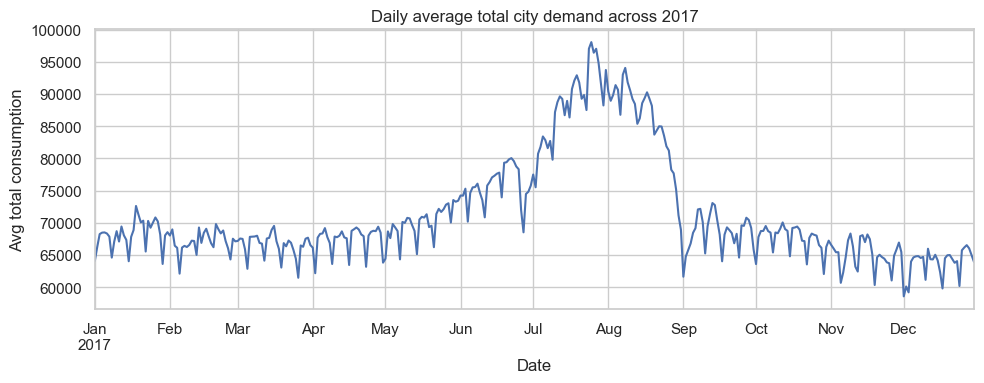

In [8]:
# I take a daily average so the shape across the whole year is easy to read.
daily = df["TotalConsumption"].resample("D").mean()
plt.figure()
daily.plot()
plt.title("Daily average total city demand across 2017")
plt.xlabel("Date")
plt.ylabel("Avg total consumption")
plt.tight_layout()
plt.show()


**What I make of it:** When I look at the demand across the year there is a clear seasonal story sitting in front of me, because it starts off high during the cold winter, it eases off a little as spring arrives, and then it climbs to its highest point of the whole year in the middle of summer around July and August, and my best explanation for that summer peak is air conditioning being pushed hard in the Moroccan heat, which already tells me that the month of the year is going to earn its place as a feature.

### Q2. What does an average day look like when I break it down by hour?

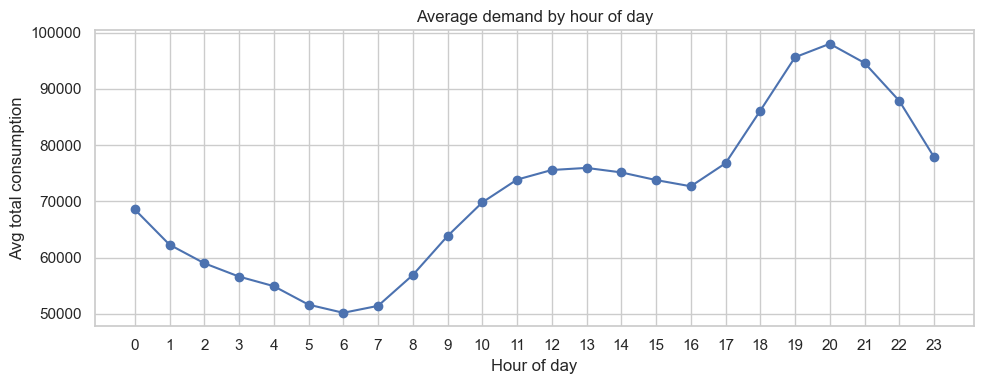

In [9]:
# I group by the hour of the day and average the demand for each hour.
by_hour = df.groupby(df.index.hour)["TotalConsumption"].mean()
plt.figure()
by_hour.plot(marker="o")
plt.title("Average demand by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Avg total consumption")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**What I make of it:** The daily rhythm here is honestly one of the strongest patterns I found in the whole dataset, because the demand sinks to its lowest in the dead of night somewhere between three and six in the morning when most of the city is asleep, and then it works its way up through the day until it hits a clear evening peak around seven to nine at night when people are back home cooking and switching things on, and this single picture is the main reason I later feed the hour of the day straight into the model.

### Q3. Are weekdays actually different from weekends?

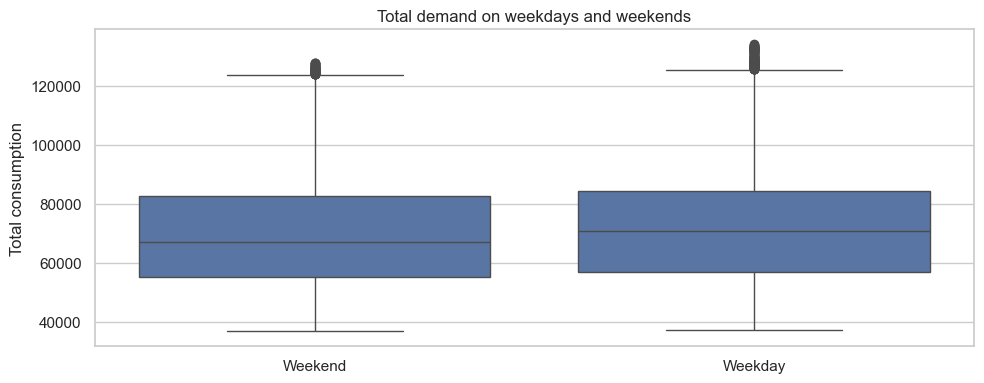

day_type
Weekday    71999.1
Weekend    69282.2
Name: TotalConsumption, dtype: float64


In [10]:
# I label each row as a weekday or a weekend and put the two side by side.
tmp = df.copy()
tmp["day_type"] = np.where(tmp.index.dayofweek >= 5, "Weekend", "Weekday")
plt.figure()
sns.boxplot(data=tmp, x="day_type", y="TotalConsumption")
plt.title("Total demand on weekdays and weekends")
plt.xlabel("")
plt.ylabel("Total consumption")
plt.tight_layout()
plt.show()

print(tmp.groupby("day_type")["TotalConsumption"].mean().round(1))


**What I make of it:** The gap between weekdays and weekends turned out to be smaller than I first expected, but it is definitely there, because the weekdays sit a little higher on average, and the reason that makes sense to me is that shops and offices and other businesses are open and drawing power during the working week in a way they are not on a quiet Saturday or Sunday, and even though the difference is modest it is consistent enough that I felt it was worth keeping a weekend flag for the model to use.

### Q4. Required lag question. How closely tied is the demand to its own recent past?

This is the question that I personally found the most fun to dig into, because electricity demand has this habit of looking a lot like it did a short while earlier, and to actually see how strong that habit is I built the lag features and then studied two things, first an autocorrelation plot that tells me how similar the series is to shifted copies of itself, and second a scatter of the demand against its value from exactly one day earlier, which I call lag_144 for the simple reason that a hundred and forty four steps of ten minutes add up to a full twenty four hours.

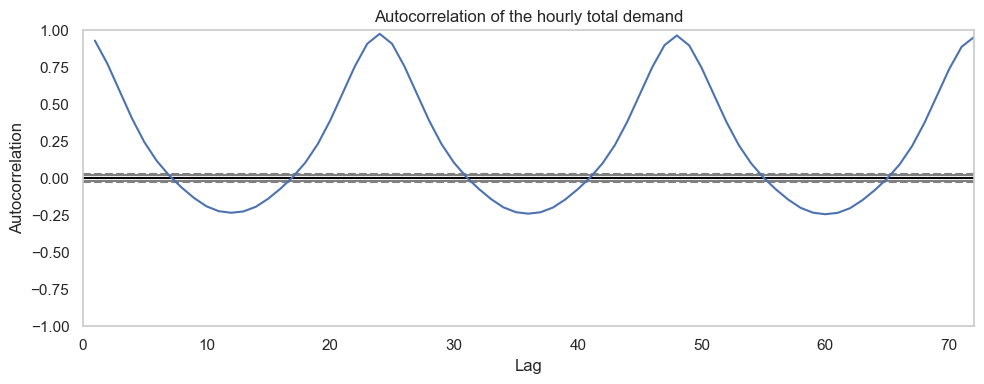

In [11]:
from pandas.plotting import autocorrelation_plot

# I downsample to hourly here only so the autocorrelation plot stays readable.
hourly = df["TotalConsumption"].resample("h").mean()
plt.figure(figsize=(10, 4))
autocorrelation_plot(hourly)
plt.title("Autocorrelation of the hourly total demand")
plt.xlim(0, 72)
plt.tight_layout()
plt.show()


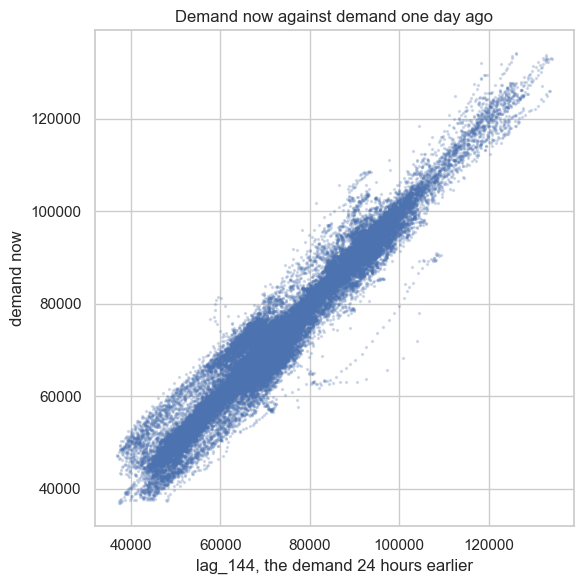

Correlation with lag_1, which is ten minutes ago: 0.997
Correlation with lag_144, which is one day ago: 0.979


In [12]:
# I build the features and then scatter the demand against its value one day ago.
feat = pp.build_features(df)

plt.figure(figsize=(6, 6))
plt.scatter(feat["lag_144"], feat["TotalConsumption"], s=2, alpha=0.2)
plt.title("Demand now against demand one day ago")
plt.xlabel("lag_144, the demand 24 hours earlier")
plt.ylabel("demand now")
plt.tight_layout()
plt.show()

print("Correlation with lag_1, which is ten minutes ago:",
      round(feat["TotalConsumption"].corr(feat["lag_1"]), 3))
print("Correlation with lag_144, which is one day ago:",
      round(feat["TotalConsumption"].corr(feat["lag_144"]), 3))


**What I make of it:** The autocorrelation plot shows strong spikes that come back every twenty four hours like clockwork, which is really just a mathematical way of saying that today at eight in the evening looks an awful lot like yesterday at eight in the evening, and when I plotted the demand against its value one day earlier the points fell almost neatly along a straight line with a correlation sitting close to nine tenths, and the ten minute lag was stronger still, so this was honestly the moment where it clicked for me that the recent past was going to be the single most powerful thing I could hand to the model.

### Q5. Required moving average question. Raw demand next to a one day moving average

A moving average is my favourite way of quietly turning down the noise so that the slower trend underneath can show itself, and to make the difference really obvious I picked out a single month rather than the whole year, because plotting everything at once turns into an unreadable mess, and then I laid the raw ten minute line and its one day moving average on the same chart so the contrast between the two is impossible to miss.

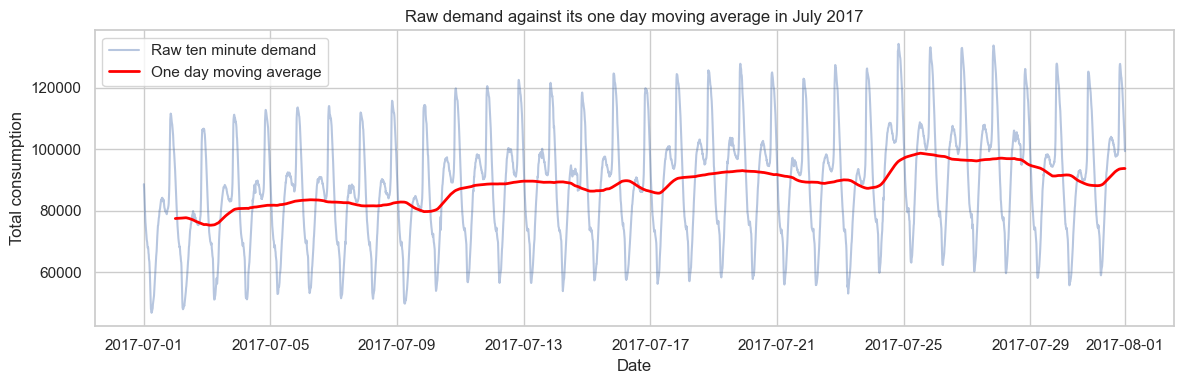

In [13]:
# I take one month so the two lines are easy to compare.
month = df.loc["2017-07", "TotalConsumption"]
# A window of 144 steps of ten minutes is exactly one full day.
roll_1day = month.rolling(window=144).mean()

plt.figure(figsize=(12, 4))
plt.plot(month.index, month.values, alpha=0.4, label="Raw ten minute demand")
plt.plot(roll_1day.index, roll_1day.values, color="red", linewidth=2,
         label="One day moving average")
plt.title("Raw demand against its one day moving average in July 2017")
plt.xlabel("Date")
plt.ylabel("Total consumption")
plt.legend()
plt.tight_layout()
plt.show()


**What I make of it:** The raw line is jagged and busy because it is carrying every little daily swing and every bit of random noise all at once, whereas the red moving average glides along much more calmly and shows me the general level of demand as it drifts across the month, and seeing them together is exactly why I decided to give the model both kinds of information, since the raw lags tell it the precise recent value while the moving averages tell it the slower background level that the value is moving around.

### Q6. How do the weather variables relate to the demand?

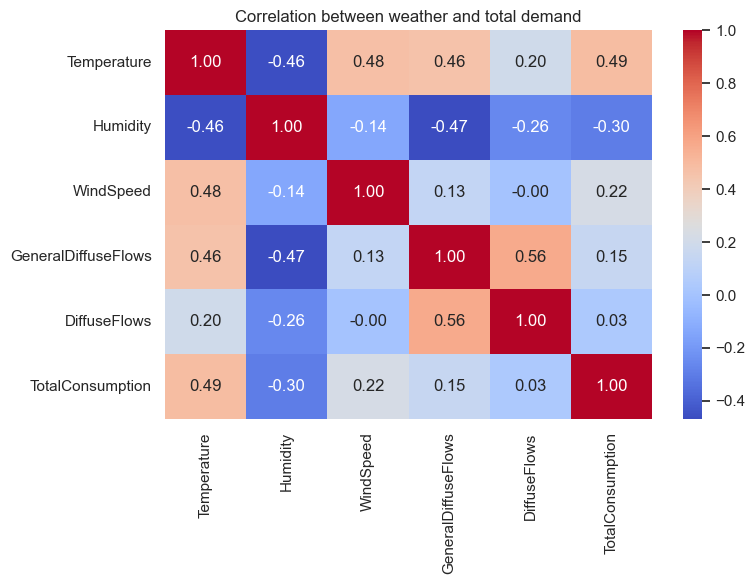

In [14]:
# A correlation heatmap between the weather columns and the total demand.
corr_cols = ["Temperature", "Humidity", "WindSpeed",
             "GeneralDiffuseFlows", "DiffuseFlows", "TotalConsumption"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between weather and total demand")
plt.tight_layout()
plt.show()


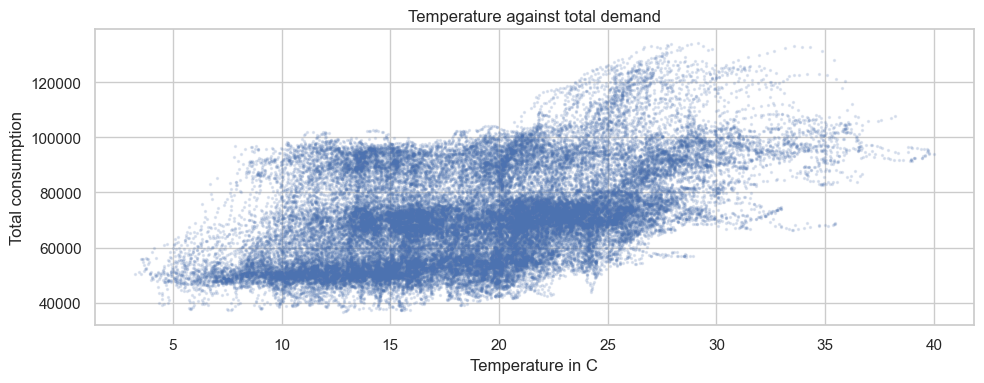

In [15]:
# A scatter of temperature against demand, since it was the strongest of the weather columns.
plt.figure()
plt.scatter(df["Temperature"], df["TotalConsumption"], s=2, alpha=0.15)
plt.title("Temperature against total demand")
plt.xlabel("Temperature in C")
plt.ylabel("Total consumption")
plt.tight_layout()
plt.show()


**What I make of it:** Out of all the weather columns it is the temperature that has the clearest positive pull on the demand, so the hotter hours tend to drag the demand upward in a way that fits my earlier idea about cooling in the summer, while the humidity has a gentler link in the opposite direction and the wind and the solar radiation values barely move together with demand at all, and the takeaway I hold onto is that the weather genuinely helps but it is nowhere near as strong a signal as the demand lags I found back in question four.

## C. Building the features

Every bit of my feature code lives inside one function called build_features over in src/preprocessing.py, and I set it up that way on purpose because I knew Task 4 would need to prepare a fresh record in exactly the same manner before it could predict anything, and if I had copied the logic into two different places they would slowly fall out of step and the model would end up being fed the wrong columns without anybody noticing, so keeping a single function means there is only ever one honest version of the truth. Below I simply call that function and take a look at what falls out of it, and the features come in three families, the calendar ones such as the hour and the day of the week and the month and a weekend flag, the lag ones which are the demand ten minutes ago and one hour ago and one day ago, and the moving averages over the last hour and the last day, with the empty leading rows dropped inside the function as I explained earlier.

In [16]:
feat = pp.build_features(df)
print("Before features:", df.shape, "after build_features:", feat.shape)
print("Rows dropped because of the lags and rolling:", len(df) - len(feat))
print("The columns the model will use:")
print(pp.FEATURE_COLUMNS)
feat[pp.FEATURE_COLUMNS].head()


Before features: (52416, 9) after build_features: (52272, 18)
Rows dropped because of the lags and rolling: 144
The columns the model will use:
['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_6', 'lag_144', 'roll_mean_6', 'roll_mean_144']


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,hour,dayofweek,month,is_weekend,lag_1,lag_6,lag_144,roll_mean_6,roll_mean_144
Datetime,,,,,,,,,,,,,,
2017-01-02 00:00:00,11.01,75.8,0.076,0.033,0.163,0,0,1,0,65096.35700,74057.22885,70425.53544,69757.481648,64071.818534
2017-01-02 00:10:00,10.74,77.3,0.078,0.084,0.108,0,0,1,0,62667.35846,72523.47217,69320.84387,67859.169917,64017.942305
2017-01-02 00:20:00,10.47,78.2,0.078,0.088,0.130,0,0,1,0,61026.11029,70945.30824,67803.22193,65942.942937,63960.339989
2017-01-02 00:30:00,10.31,79.2,0.076,0.091,0.134,0,0,1,0,59728.31136,68756.76906,65489.23209,64073.443457,63904.264221
2017-01-02 00:40:00,10.63,79.3,0.079,0.037,0.152,0,0,1,0,58343.58633,67165.75457,63650.44627,62337.913002,63854.641681


## D. Training the models and comparing them

When it came to splitting the data I had to be careful, because with a time series I cannot just shuffle the rows around like I would for an ordinary table, and the reason is that shuffling would let some future rows sneak into the training set where the model could effectively peek at answers it should never be allowed to see, which flatters the scores in a way that means nothing in the real world, so instead I trained on the first eighty percent of the timeline and tested on the last twenty percent with no shuffling whatsoever. The fully tuned version of this training lives in src/train.py, but I repeat a lighter version of the comparison right here so that the results are visible inside the notebook where I did all my thinking.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X, y = pp.get_X_y(feat)

# My time based split, deliberately without any shuffling.
split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train ends:", X_train.index[-1], "Test starts:", X_test.index[0])


Train: (41817, 14) Test: (10455, 14)
Train ends: 2017-10-19 09:20:00 Test starts: 2017-10-19 09:30:00


In [18]:
def scores(name, y_true, y_pred):
    return {"model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred)}

results = []

# My first experiment is a Linear Regression sitting behind a scaler.
lin = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
lin.fit(X_train, y_train)
results.append(scores("LinearRegression", y_test, lin.predict(X_test)))

# My second experiment is a Random Forest with a sensible setting.
rf = RandomForestRegressor(n_estimators=200, max_depth=20,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(scores("RandomForest", y_test, rf.predict(X_test)))

comparison = pd.DataFrame(results).set_index("model").round(2)
comparison


,MAE,RMSE,R2
model,,,
LinearRegression,473.67,721.34,1.0
RandomForest,441.00,659.57,1.0


**What the table tells me:** Both of my models do genuinely well, which did not shock me in the slightest after I had already seen how much muscle the lag features were carrying back in question four, and the Random Forest nudges ahead of the linear model on the error numbers, which I put down to its ability to pick up on the way features combine in a non linear fashion, for example the hour of the day interacting with the temperature rather than each acting on its own. The full script src/train.py runs a small search over the Random Forest settings and saves whichever one comes out best into models/model.pkl, and that saved model is the exact one that the prediction script later loads.

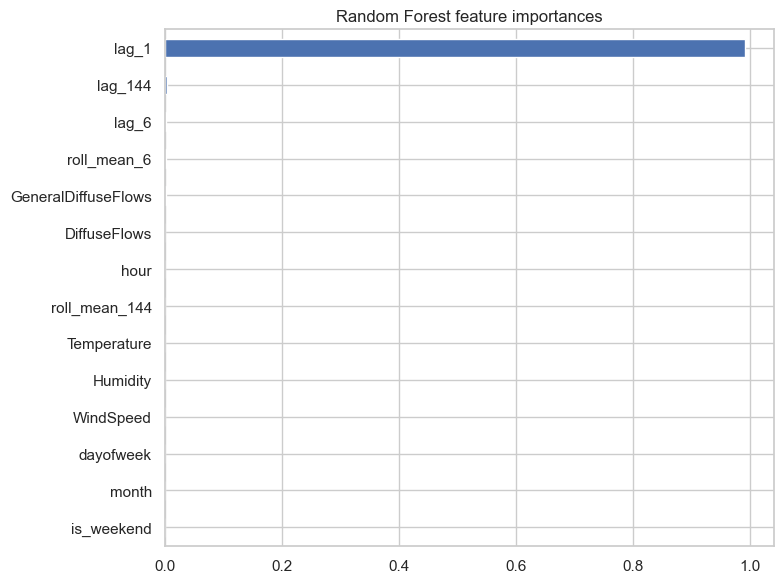

In [19]:
# I check which features the Random Forest leans on the most.
importances = pd.Series(rf.feature_importances_, index=pp.FEATURE_COLUMNS)
importances.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()


**What I make of it:** Just as question four had already hinted to me, the recent past features rise to the top of the pile, especially the ten minute lag and the moving averages, while the calendar and the weather settle into a smaller supporting role, and this lines up perfectly with the plain common sense idea that the demand ten minutes from now is mostly going to be about the same as it is right now, with only a gentle nudge coming from the time of day and whatever the weather happens to be doing.

### A short summary of my Task 1

To pull all of my work together, the data arrived complete with no missing values, and the only gaps I ever had to manage were the ones my own features created, which I simply dropped. I found clear daily and weekly and seasonal patterns, which is why the calendar features earn their keep, and the demand turned out to be tied so tightly to its own recent past that the lag features became the biggest signal by a wide margin, with the moving averages giving me a smoothed view of the trend sitting on top of that. In the end I chose the Random Forest as my model and saved it, so that the API and the prediction script built by my teammates would have something ready to load.
